In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import sunpy
import sunpy.map
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
import astropy.units as u
from ndcube import NDCube
from scipy.io import readsav
from skimage import measure
import skimage.measure.profile
from skimage.transform import rescale
import matplotlib.lines as mlines
from matplotlib.patches import Polygon
from sunpy.coordinates import get_earth
import cv2

In [2]:
file_Halpha_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Halpha_BLZNL_pr.hdf5")
Halpha_pr_set = file_Halpha_pr["vbi_img"]
Halpha_pr_da = da.from_array(Halpha_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Halpha_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Halpha_BLZNL_date_avg.txt")["DATE-AVG"])

In [3]:
Halpha_pr_rebin = np.nanmean(Halpha_pr_da.reshape([Halpha_pr_da.shape[0],
                    Halpha_pr_da.shape[1]//4, 4,
                    Halpha_pr_da.shape[2]//4, 4]), axis=(2,4))
Halpha_pr_rebin = Halpha_pr_rebin.compute()

In [4]:
file_Hbeta_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [5]:
Hbeta_pr_rebin = np.nanmean(Hbeta_pr_da.reshape([Hbeta_pr_da.shape[0],
                    Hbeta_pr_da.shape[1]//4, 4,
                    Hbeta_pr_da.shape[2]//4, 4]), axis=(2,4))
Hbeta_pr_rebin = Hbeta_pr_rebin.compute()

In [6]:
file_aia171_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/AIA_171_pr.hdf5")
aia171_pr_set = file_aia171_pr_dset["aia_171_img"]
aia171_pr_da = da.from_array(aia171_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
aia171_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/AIA_171_date_obs.txt")["date_obs"])

In [7]:
def get_stackplot_intensity_memory_efficient(x_select, y_select, eui_map_cube, linewidth=8*2, chunk_size=100):
    """
    Memory-efficient version that processes in chunks
    """
    # Calculate line profile coordinates once
    pixels_idy, pixels_idx = measure.profile._line_profile_coordinates(
        (y_select[0], x_select[0]), (y_select[1], x_select[1]), linewidth=linewidth
    )

    # Pre-calculate static values
    pixels_idy_center = np.nanmean(pixels_idy, axis=1)
    pixels_idx_center = np.nanmean(pixels_idx, axis=1)

    pixel_distance = np.cumsum(np.sqrt(np.diff(pixels_idx_center)**2 + np.diff(pixels_idy_center)**2))
    pixel_distance = np.insert(pixel_distance, 0, 0)
    pixel_distance_interp = np.linspace(pixel_distance[0], pixel_distance[-1], len(pixel_distance))

    num_time_steps = eui_map_cube.shape[0]
    intensity = np.empty((num_time_steps, len(pixel_distance_interp)))

    # Process in chunks to manage memory
    for start_idx in range(0, num_time_steps, chunk_size):
        end_idx = min(start_idx + chunk_size, num_time_steps)
        
        # Compute chunk
        if hasattr(eui_map_cube, 'compute'):
            chunk = eui_map_cube[start_idx:end_idx].compute()
        else:
            chunk = eui_map_cube[start_idx:end_idx]
        
        # Process chunk
        for i, tt in enumerate(range(start_idx, end_idx)):
            line = measure.profile_line(
                chunk[i], 
                (y_select[0], x_select[0]), 
                (y_select[1], x_select[1]),
                linewidth=linewidth
            )
            intensity[tt] = np.interp(pixel_distance_interp, pixel_distance, line)

    slit_intensity = intensity.T
    # slit_intensity = slit_intensity - cv2.GaussianBlur(slit_intensity, (1, 31), 0, 9)

    return slit_intensity, pixels_idx, pixels_idy

In [23]:
def get_stackplot_intensity(x_select, y_select, eui_map_cube, linewidth=8*2):
    pixels_idy, pixels_idx = measure.profile._line_profile_coordinates((y_select[0], x_select[0]),
                            (y_select[1], x_select[1]), linewidth=linewidth)

    pixels_idy_center = np.nanmean(pixels_idy,axis=1)
    pixels_idx_center = np.nanmean(pixels_idx,axis=1)

    pixel_distance = np.cumsum(np.sqrt(np.diff(pixels_idx_center)**2 + np.diff(pixels_idy_center)**2))
    pixel_distance = np.insert(pixel_distance,0,0)
    pixel_distance_interp = np.linspace(pixel_distance[0],pixel_distance[-1],len(pixel_distance))

    intensity = []

    for tt in range(eui_map_cube.shape[0]):
        try:
            eui_map_ii = eui_map_cube[tt,:,:].compute()
        except:
            eui_map_ii = eui_map_cube[tt,:,:]
        # eui_map_ii = eui_map_cube[tt,:,:].compute()
        line = measure.profile_line(eui_map_ii, 
                                    (y_select[0], x_select[0]), (y_select[1], x_select[1]),
                                    linewidth=linewidth)
        
        intensity_interp = np.interp(pixel_distance_interp,pixel_distance,line)
        intensity.append(intensity_interp)

    slit_intensity = np.array(intensity).T
    # slit_intensity = slit_intensity - cv2.GaussianBlur(slit_intensity,(1,31),0,9)

    # slit_intensity = slit_intensity/np.nanmean(slit_intensity, axis=1)[:, np.newaxis]
    # slit_intensity = slit_intensity/np.nanmean(slit_intensity, axis=0)[np.newaxis, :]

    return slit_intensity, pixels_idx, pixels_idy

In [9]:
def plot_slit_position(pixels_idx, pixels_idy, ax1, triangle_length=20, triangle_anchor_index=40, triangle_ratio=0.6,
                       color='#58B2DC', lw=1, alpha=0.5, text=None, text_color=None, text_offset=5, text_fontsize=10):
    boundary_x = np.concatenate((pixels_idx[:, 0], pixels_idx[-1, 1:], pixels_idx[-1::-1, -1], pixels_idx[0, -1::-1]))
    boundary_y = np.concatenate((pixels_idy[:, 0], pixels_idy[-1, 1:], pixels_idy[-1::-1, -1], pixels_idy[0, -1::-1]))

    slit_boundary_collection = []
    boundary_x_line2d_ax1 = mlines.Line2D(boundary_x, boundary_y, color=color, lw=lw, alpha=alpha)
    boundary_x_line2d_ax2 = mlines.Line2D(boundary_x, boundary_y, color=color, lw=lw, alpha=alpha)
    slit_boundary_collection.append(ax1.add_line(boundary_x_line2d_ax1))

    triangle_anchor_point_0 = np.array([pixels_idx[triangle_anchor_index, 0], pixels_idy[triangle_anchor_index, 0]])
    triangle_anchor_point_1 = np.array([pixels_idx[triangle_anchor_index + triangle_length, 0], pixels_idy[triangle_anchor_index + triangle_length, 0]])
    triangle_bottom_vec = triangle_anchor_point_1 - triangle_anchor_point_0
    triangle_bottom_vec_rot_90 = np.array([triangle_bottom_vec[1], -triangle_bottom_vec[0]])*triangle_ratio
    triangle_anchor_point_2 = triangle_anchor_point_0 + triangle_bottom_vec_rot_90

    triangle_points = np.vstack((triangle_anchor_point_0, triangle_anchor_point_1, triangle_anchor_point_2,))
    
    for ax_ in (ax1,):
        triangle_patch = Polygon(triangle_points, closed=True, edgecolor=color, facecolor=color, alpha=alpha)
        ax_.add_patch(triangle_patch)

    if text is not None:
        if text_color is None:
            text_color = color
        slit_center_x = np.nanmean(pixels_idx)
        slit_center_y = np.nanmean(pixels_idy)
        triangle_bottom_vec_rot_90_norm = triangle_bottom_vec_rot_90/np.linalg.norm(triangle_bottom_vec_rot_90)

        for ax_ in (ax1,):
            ax_.text(slit_center_x + text_offset*triangle_bottom_vec_rot_90_norm[0], 
                     slit_center_y + text_offset*triangle_bottom_vec_rot_90_norm[1], text,
                    color=text_color, fontsize=text_fontsize, ha='center', va='center',
                    )


    return slit_boundary_collection

In [10]:
Halpha_pr_da.shape

(433, 3840, 3840)

In [11]:
Hbeta_pr_da.shape

(282, 3840, 3840)

In [12]:
Halpha_date_obs[0], Halpha_date_obs[-1]

(<Time object: scale='utc' format='isot' value=2022-10-24T18:58:09.707>,
 <Time object: scale='utc' format='isot' value=2022-10-24T19:42:02.027>)

In [13]:
Hbeta_date_obs[0], Hbeta_date_obs[-1]

(<Time object: scale='utc' format='isot' value=2022-10-24T18:59:13.688>,
 <Time object: scale='utc' format='isot' value=2022-10-24T19:42:02.028>)

In [14]:
aia171_date_obs[0], aia171_date_obs[-1]

(<Time object: scale='utc' format='isot' value=2022-10-24T19:04:09.352>,
 <Time object: scale='utc' format='isot' value=2022-10-24T19:35:57.352>)

In [15]:
Halpha_start_index = np.argmin(np.abs(Halpha_date_obs - aia171_date_obs[0]))
Halpha_end_index = np.argmin(np.abs(Halpha_date_obs - aia171_date_obs[-1]))

Hbeta_start_index = np.argmin(np.abs(Hbeta_date_obs - aia171_date_obs[0]))
Hbeta_end_index = np.argmin(np.abs(Hbeta_date_obs - aia171_date_obs[-1]))

Halpha_date_diff = np.abs(np.nanmean(np.diff(Halpha_date_obs))).to_value(u.s)
Halpha_time_extent = np.array([-0.5, Halpha_end_index - Halpha_start_index + 1 - 0.5])*Halpha_date_diff + \
    (Halpha_date_obs[Halpha_start_index] - aia171_date_obs[0]).to_value(u.s)

Hbeta_date_diff = np.abs(np.nanmean(np.diff(Hbeta_date_obs))).to_value(u.s)
Hbeta_time_extent = np.array([-0.5, Hbeta_end_index - Hbeta_start_index + 1 - 0.5])*Hbeta_date_diff + \
    (Hbeta_date_obs[Hbeta_start_index] - aia171_date_obs[0]).to_value(u.s)

aia_date_diff = np.abs(np.nanmean(np.diff(aia171_date_obs))).to_value(u.s)
aia_time_extent = np.array([-0.5, len(aia171_date_obs) - 1 - 0.5])*aia_date_diff + \
    (aia171_date_obs[0] - aia171_date_obs[0]).to_value(u.s)

In [16]:
Halpha_pr_rebin.shape

(433, 960, 960)

In [17]:
xselect_1 = (380, 246)
yselect_1 = (755, 783)
line_width_1 = 2*5

(slit_1_halpha_intensity, slit_1_halpha_pixels_idx,
slit_1_halpha_pixels_idy) = get_stackplot_intensity_memory_efficient(
    x_select=xselect_1, y_select=yselect_1,
    eui_map_cube=Halpha_pr_rebin[Halpha_start_index:Halpha_end_index,:,:], linewidth=line_width_1)

(slit_1_hbeta_intensity, slit_1_hbeta_pixels_idx,
slit_1_hbeta_pixels_idy) = get_stackplot_intensity_memory_efficient(
    x_select=xselect_1, y_select=yselect_1,
    eui_map_cube=Hbeta_pr_rebin[Hbeta_start_index:Hbeta_end_index,:,:], linewidth=line_width_1)

(slit_1_aia_intensity, slit_1_aia_pixels_idx,
slit_1_aia_pixels_idy) = get_stackplot_intensity_memory_efficient(
    x_select=np.array(xselect_1)/2, y_select=np.array(yselect_1)/2,
    eui_map_cube=aia171_pr_da, linewidth=line_width_1//2)

In [27]:
xselect_2 = (390, 284)
yselect_2 = (621, 637)

slit_2_halpha_intensity, slit_2_halpha_pixels_idx, slit_2_halpha_pixels_idy = get_stackplot_intensity(
    x_select=xselect_2, y_select=yselect_2,
    eui_map_cube=Halpha_pr_rebin[Halpha_start_index:Halpha_end_index,:,:], linewidth=line_width_1)

slit_2_hbeta_intensity, slit_2_hbeta_pixels_idx, slit_2_hbeta_pixels_idy = get_stackplot_intensity(
    x_select=xselect_2, y_select=yselect_2,
    eui_map_cube=Hbeta_pr_rebin[Hbeta_start_index:Hbeta_end_index,:,:], linewidth=line_width_1)

slit_2_aia_intensity, slit_2_aia_pixels_idx, slit_2_aia_pixels_idy = get_stackplot_intensity(
    x_select=np.array(xselect_2)/2, y_select=np.array(yselect_2)/2,
    eui_map_cube=aia171_pr_da, linewidth=line_width_1//2
)

In [34]:
xselect_3 = (521,440)
yselect_3 = (475,500)

slit_3_halpha_intensity, slit_3_halpha_pixels_idx, slit_3_halpha_pixels_idy = get_stackplot_intensity(
    x_select=xselect_3, y_select=yselect_3,
    eui_map_cube=Halpha_pr_rebin[Halpha_start_index:Halpha_end_index,:,:], linewidth=line_width_1)

slit_3_hbeta_intensity, slit_3_hbeta_pixels_idx, slit_3_hbeta_pixels_idy = get_stackplot_intensity(
    x_select=xselect_3, y_select=yselect_3,
    eui_map_cube=Hbeta_pr_rebin[Hbeta_start_index:Hbeta_end_index,:,:], linewidth=line_width_1)

slit_3_aia_intensity, slit_3_aia_pixels_idx, slit_3_aia_pixels_idy = get_stackplot_intensity(
    x_select=np.array(xselect_3)/2, y_select=np.array(yselect_3)/2,
    eui_map_cube=aia171_pr_da, linewidth=line_width_1//2
)

In [18]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

pixel_scale = dkist_vbi_target_header["CDELT1"]/3600*np.pi/180*get_earth(dkist_vbi_target_header["DATE-AVG"]).radius.to_value(u.Mm)*4
length_extent_1 = np.array([-0.5, len(slit_1_halpha_pixels_idx) - 0.5])*pixel_scale

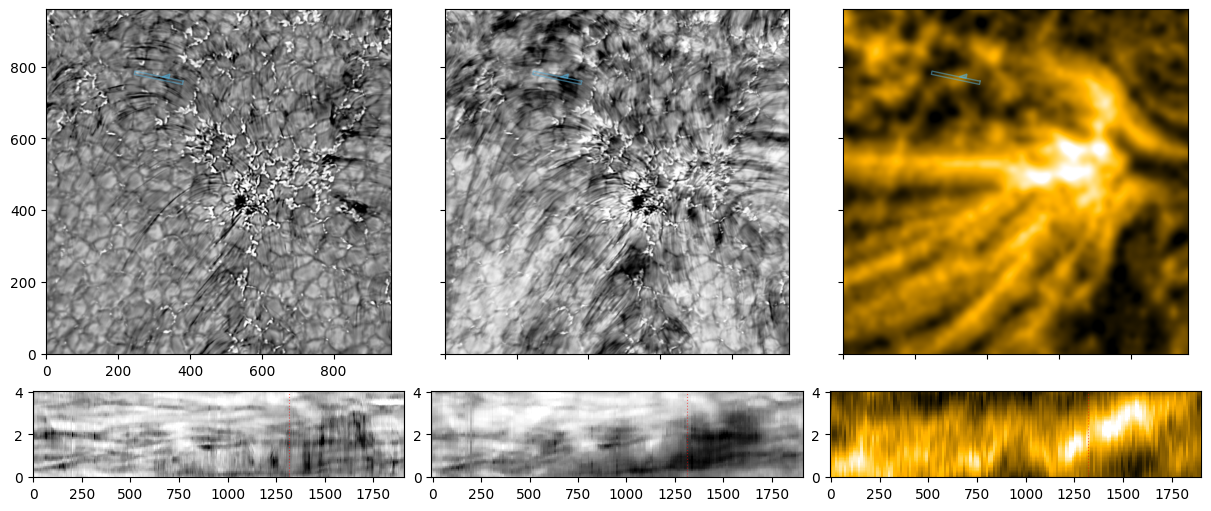

In [19]:
%matplotlib inline
fig, axes = plt.subplots(2,3, figsize=(12,5),
    layout="constrained", gridspec_kw={'height_ratios': [4,1]})

halpha_select_index = 275
hbeta_select_index = np.argmin(np.abs(Halpha_date_obs[halpha_select_index] - Hbeta_date_obs))
aia_select_index = np.argmin(np.abs(Halpha_date_obs[halpha_select_index] - aia171_date_obs))

axes[0,0].imshow(Halpha_pr_rebin[halpha_select_index,:,:], cmap="Greys_r",
        norm=ImageNormalize(vmin=np.nanpercentile(Halpha_pr_rebin[halpha_select_index,:,:], 0.5),
                                   vmax=np.nanpercentile(Halpha_pr_rebin[halpha_select_index,:,:], 99.5)),
                                   origin="lower", aspect=1)

axes[0,1].imshow(Hbeta_pr_rebin[hbeta_select_index,:,:], cmap="Greys_r",
        norm=ImageNormalize(
        vmin=np.nanpercentile(Hbeta_pr_rebin[hbeta_select_index,:,:], 0.5),
        vmax=np.nanpercentile(Hbeta_pr_rebin[hbeta_select_index,:,:], 99.5)),
        origin="lower", aspect=1)

axes[0,2].imshow(rescale(aia171_pr_da[aia_select_index,:,:].compute(), 2.0, anti_aliasing=True),
        cmap="sdoaia171",
        norm=ImageNormalize(
        vmin=np.nanpercentile(aia171_pr_da[aia_select_index,:,:].compute(), 0.5),
        vmax=np.nanpercentile(aia171_pr_da[aia_select_index,:,:].compute(), 99.5)),
        origin="lower", aspect=1)

for ax_ in axes[0,:]:
    plot_slit_position(slit_1_halpha_pixels_idx, slit_1_halpha_pixels_idy, ax_, text=None, text_offset=200)

axes[1,0].imshow(slit_1_halpha_intensity, cmap="Greys_r", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_1_halpha_intensity, 0.1),
    vmax=np.nanpercentile(slit_1_halpha_intensity, 99.)),
    aspect="auto",
    extent=[*Halpha_time_extent, *length_extent_1])

axes[1,1].imshow(slit_1_hbeta_intensity, cmap="Greys_r", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_1_hbeta_intensity, 0.1),
    vmax=np.nanpercentile(slit_1_hbeta_intensity, 99.)),
    aspect="auto",
    extent=[*Hbeta_time_extent, *length_extent_1])

axes[1,2].imshow(slit_1_aia_intensity, cmap="sdoaia171", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_1_aia_intensity, 0.1),
    vmax=np.nanpercentile(slit_1_aia_intensity, 99.)),
    aspect="auto",
    extent=[*aia_time_extent, *length_extent_1])

axes[1,0].axvline((Halpha_date_obs[halpha_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")

axes[1,1].axvline((Hbeta_date_obs[hbeta_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")

axes[1,2].axvline((aia171_date_obs[aia_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")



for ax_ in (axes[0,1],axes[0,2]):
    ax_.tick_params(labelleft=False, labelbottom=False)
    ax_.sharex(axes[0,0])
    ax_.sharey(axes[0,0])

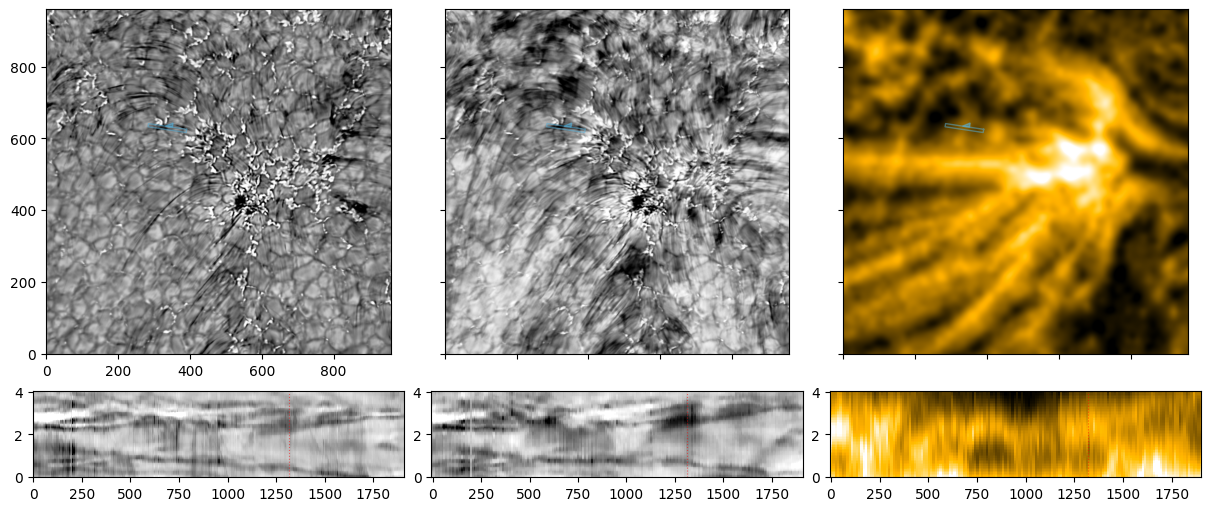

In [36]:
%matplotlib inline
fig, axes = plt.subplots(2,3, figsize=(12,5),
    layout="constrained", gridspec_kw={'height_ratios': [4,1]})

halpha_select_index = 275
hbeta_select_index = np.argmin(np.abs(Halpha_date_obs[halpha_select_index] - Hbeta_date_obs))
aia_select_index = np.argmin(np.abs(Halpha_date_obs[halpha_select_index] - aia171_date_obs))

axes[0,0].imshow(Halpha_pr_rebin[halpha_select_index,:,:], cmap="Greys_r",
        norm=ImageNormalize(vmin=np.nanpercentile(Halpha_pr_rebin[halpha_select_index,:,:], 0.5),
                                   vmax=np.nanpercentile(Halpha_pr_rebin[halpha_select_index,:,:], 99.5)),
                                   origin="lower", aspect=1)

axes[0,1].imshow(Hbeta_pr_rebin[hbeta_select_index,:,:], cmap="Greys_r",
        norm=ImageNormalize(
        vmin=np.nanpercentile(Hbeta_pr_rebin[hbeta_select_index,:,:], 0.5),
        vmax=np.nanpercentile(Hbeta_pr_rebin[hbeta_select_index,:,:], 99.5)),
        origin="lower", aspect=1)

axes[0,2].imshow(rescale(aia171_pr_da[aia_select_index,:,:].compute(), 2.0, anti_aliasing=True),
        cmap="sdoaia171",
        norm=ImageNormalize(
        vmin=np.nanpercentile(aia171_pr_da[aia_select_index,:,:].compute(), 0.5),
        vmax=np.nanpercentile(aia171_pr_da[aia_select_index,:,:].compute(), 99.5)),
        origin="lower", aspect=1)

for ax_ in axes[0,:]:
    plot_slit_position(slit_2_halpha_pixels_idx, slit_2_halpha_pixels_idy, ax_, text=None, text_offset=200)

axes[1,0].imshow(slit_2_halpha_intensity, cmap="Greys_r", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_2_halpha_intensity, 0.1),
    vmax=np.nanpercentile(slit_2_halpha_intensity, 99.)),
    aspect="auto",
    extent=[*Halpha_time_extent, *length_extent_1])

axes[1,1].imshow(slit_2_hbeta_intensity, cmap="Greys_r", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_2_hbeta_intensity, 0.1),
    vmax=np.nanpercentile(slit_2_hbeta_intensity, 99.)),
    aspect="auto",
    extent=[*Hbeta_time_extent, *length_extent_1])

axes[1,2].imshow(slit_2_aia_intensity, cmap="sdoaia171", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_2_aia_intensity, 0.1),
    vmax=np.nanpercentile(slit_2_aia_intensity, 99.)),
    aspect="auto",
    extent=[*aia_time_extent, *length_extent_1])

axes[1,0].axvline((Halpha_date_obs[halpha_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")

axes[1,1].axvline((Hbeta_date_obs[hbeta_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")

axes[1,2].axvline((aia171_date_obs[aia_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")



for ax_ in (axes[0,1],axes[0,2]):
    ax_.tick_params(labelleft=False, labelbottom=False)
    ax_.sharex(axes[0,0])
    ax_.sharey(axes[0,0])

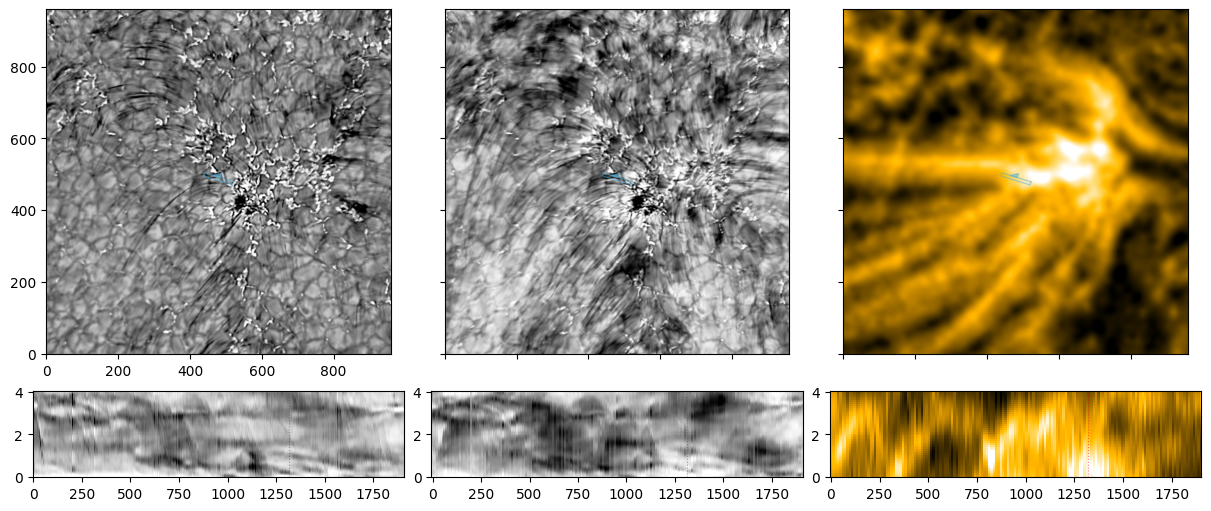

In [37]:
%matplotlib inline
fig, axes = plt.subplots(2,3, figsize=(12,5),
    layout="constrained", gridspec_kw={'height_ratios': [4,1]})

halpha_select_index = 275
hbeta_select_index = np.argmin(np.abs(Halpha_date_obs[halpha_select_index] - Hbeta_date_obs))
aia_select_index = np.argmin(np.abs(Halpha_date_obs[halpha_select_index] - aia171_date_obs))

axes[0,0].imshow(Halpha_pr_rebin[halpha_select_index,:,:], cmap="Greys_r",
        norm=ImageNormalize(vmin=np.nanpercentile(Halpha_pr_rebin[halpha_select_index,:,:], 0.5),
                                   vmax=np.nanpercentile(Halpha_pr_rebin[halpha_select_index,:,:], 99.5)),
                                   origin="lower", aspect=1)

axes[0,1].imshow(Hbeta_pr_rebin[hbeta_select_index,:,:], cmap="Greys_r",
        norm=ImageNormalize(
        vmin=np.nanpercentile(Hbeta_pr_rebin[hbeta_select_index,:,:], 0.5),
        vmax=np.nanpercentile(Hbeta_pr_rebin[hbeta_select_index,:,:], 99.5)),
        origin="lower", aspect=1)

axes[0,2].imshow(rescale(aia171_pr_da[aia_select_index,:,:].compute(), 2.0, anti_aliasing=True),
        cmap="sdoaia171",
        norm=ImageNormalize(
        vmin=np.nanpercentile(aia171_pr_da[aia_select_index,:,:].compute(), 0.5),
        vmax=np.nanpercentile(aia171_pr_da[aia_select_index,:,:].compute(), 99.5)),
        origin="lower", aspect=1)

for ax_ in axes[0,:]:
    plot_slit_position(slit_3_halpha_pixels_idx, slit_3_halpha_pixels_idy, ax_, text=None, text_offset=200)

axes[1,0].imshow(slit_3_halpha_intensity, cmap="Greys_r", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_3_halpha_intensity, 0.1),
    vmax=np.nanpercentile(slit_3_halpha_intensity, 99.)),
    aspect="auto",
    extent=[*Halpha_time_extent, *length_extent_1])

axes[1,1].imshow(slit_3_hbeta_intensity, cmap="Greys_r", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_3_hbeta_intensity, 0.1),
    vmax=np.nanpercentile(slit_3_hbeta_intensity, 99.)),
    aspect="auto",
    extent=[*Hbeta_time_extent, *length_extent_1])

axes[1,2].imshow(slit_3_aia_intensity, cmap="sdoaia171", origin="lower", interpolation="none",
 norm=ImageNormalize(
    vmin=np.nanpercentile(slit_3_aia_intensity, 0.1),
    vmax=np.nanpercentile(slit_3_aia_intensity, 99.)),
    aspect="auto",
    extent=[*aia_time_extent, *length_extent_1])

axes[1,0].axvline((Halpha_date_obs[halpha_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")

axes[1,1].axvline((Hbeta_date_obs[hbeta_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")

axes[1,2].axvline((aia171_date_obs[aia_select_index] - aia171_date_obs[0]).to_value(u.s),
                  color="r", linewidth=0.8, alpha=0.5, ls=":")



for ax_ in (axes[0,1],axes[0,2]):
    ax_.tick_params(labelleft=False, labelbottom=False)
    ax_.sharex(axes[0,0])
    ax_.sharey(axes[0,0])

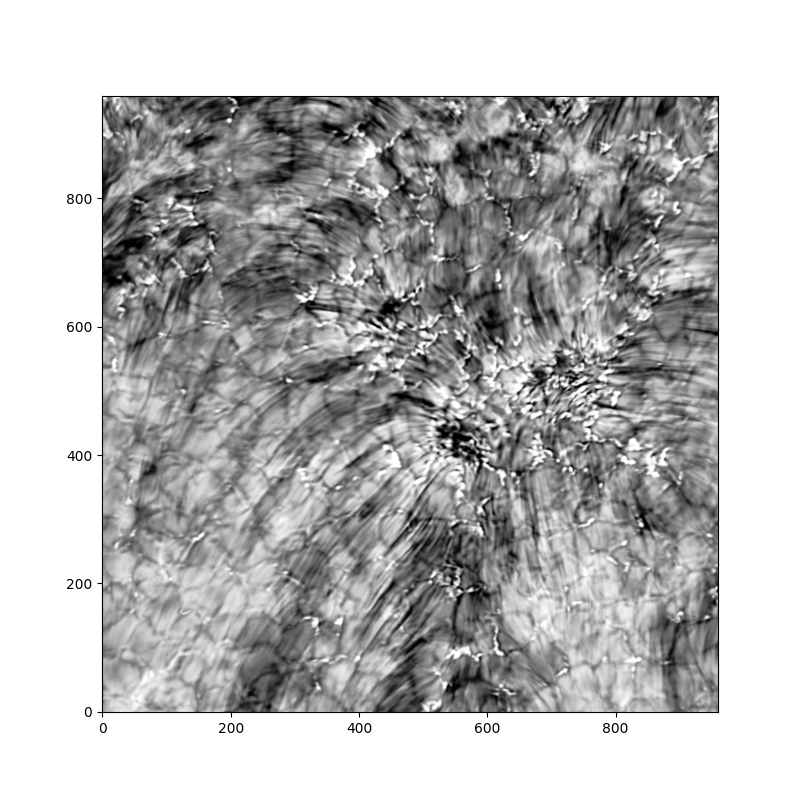

In [33]:
%matplotlib ipympl

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(Hbeta_pr_rebin[100,:,:], cmap="Greys_r",
        norm=ImageNormalize(
        vmin=np.nanpercentile(Hbeta_pr_rebin[hbeta_select_index,:,:], 0.5),
        vmax=np.nanpercentile(Hbeta_pr_rebin[hbeta_select_index,:,:], 99.5)),
        origin="lower", aspect=1)